# Modelo Simple 2

Segundo modelo más simple, con dos capas convolucionales, con el mismo tamaño de filtro y kernel

### Impotacion y preprocesado de datos

In [2]:
from importacion_preprocesado import descarga_y_carga_de_datos, preprocesamiento


tamany_img = (128,128) # tamaño reducido para colab, porque si no supera la ram
X, y = descarga_y_carga_de_datos(target_size=tamany_img)

X_train, X_val, X_test, y_train, y_val, y_test = preprocesamiento(X, y)

Dataset ya existe, solo se van a cargar las imágenes.
X shape: (4217, 128, 128, 3) y shape: (4217,)


### Modelo

In [25]:
# Importar el modelo
import sys
sys.path.append('../')

import importlib
import models.simple_2_cnn
importlib.reload(models.simple_2_cnn) # recargamos el cache para tener la ultima versión del modelo 
from models.simple_2_cnn import create_model

# Crear el modelo
model = create_model(input_shape=(128,128,3), num_classes=4, l_rate=0.01)

c:\Users\roger\miniconda3\envs\dl\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [26]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 124, 124, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,836 (11.08 KB)

 Trainable params: 2,836 (11.08 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

In [27]:
hist = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    
    epochs=110
)

Epoch 1/110
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 60ms/step - accuracy: 0.2471 - loss: 1.3858 - val_accuracy: 0.2773 - val_loss: 1.3702
Epoch 2/110
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.3053 - loss: 1.3658 - val_accuracy: 0.3294 - val_loss: 1.3388
Epoch 3/110
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.3606 - loss: 1.3276 - val_accuracy: 0.3720 - val_loss: 1.3093
Epoch 4/110
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.3768 - loss: 1.3008 - val_accuracy: 0.3922 - val_loss: 1.2812
Epoch 5/110
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.3915 - loss: 1.2769 - val_accuracy: 0.4609 - val_loss: 1.2662
Epoch 6/110
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.4203 - loss: 1.2648 - val_accuracy: 0.4621 - val_loss: 1.2610
Epoch 7/110
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.4350 - loss: 1.2567 - val_accuracy: 0.4573 - val_loss: 1.2564
Epoch 8/110
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - accuracy: 0.4365 - loss: 1.2554 - val_accuracy: 0.

### Resultados

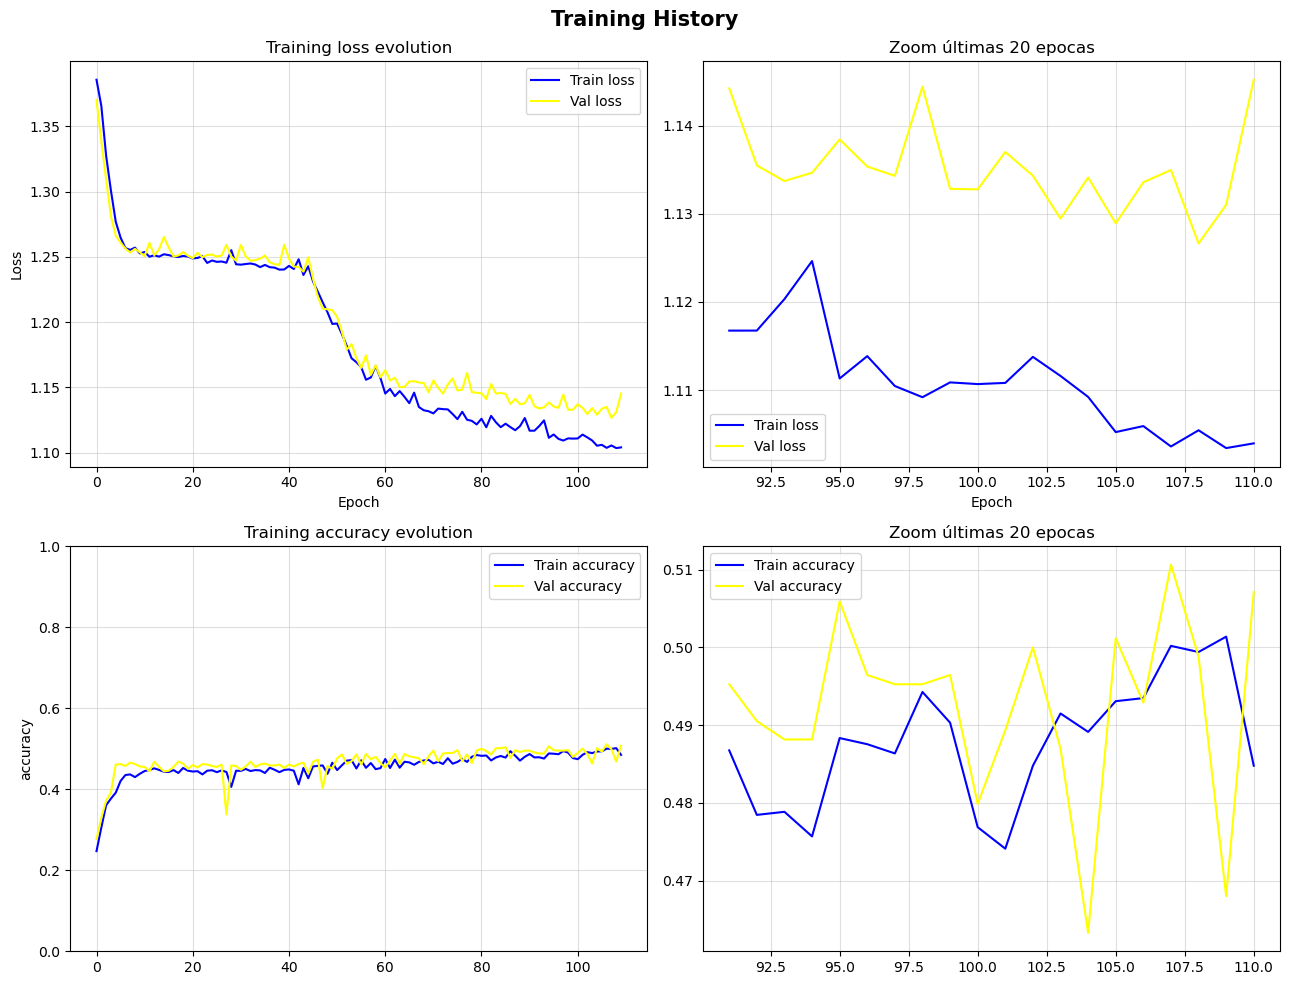

In [28]:
import matplotlib.pyplot as plt
import numpy as np

# número de épocas para el zoom
zoom_epochs = 20

loss = hist.history['loss']
val_loss = hist.history['val_loss']
acc = hist.history["accuracy"]
val_acc = hist.history["val_accuracy"]

epochs = range(1, len(loss) + 1)

fig, ax = plt.subplots(2, 2, figsize=(13,10))
ax  = ax.flatten()
fig.suptitle('Training History', fontsize=15, fontweight='bold')

# Visualizacion evolucion loss durante el entrenamiento
ax[0].plot( loss, label='Train loss', color = "blue")
ax[0].plot( val_loss, label='Val loss', color= "yellow")
ax[0].set_title('Training loss evolution')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].grid(True, alpha = 0.4)
ax[0].legend()

# Zoom últimas épocas
ax[1].plot(epochs[-zoom_epochs:], loss[-zoom_epochs:], label='Train loss', color = "blue")
ax[1].plot(epochs[-zoom_epochs:], val_loss[-zoom_epochs:], label='Val loss', color= "yellow")
ax[1].set_title(f'Zoom últimas {zoom_epochs} epocas')
ax[1].set_xlabel('Epoch')
ax[1].grid(True, alpha = 0.4)
ax[1].legend()

# Visualizacion de accuracy durante el entrenamiento
ax[2].plot( acc, label='Train accuracy', color = "blue")
ax[2].plot( val_acc, label='Val accuracy', color= "yellow")
ax[2].grid(True, alpha = 0.4)
ax[2].set_ylim(0,1)
ax[2].set_title('Training accuracy evolution')
ax[2].set_ylabel('accuracy')
ax[2].legend()

# Zoom últimas épocas
ax[3].plot(epochs[-zoom_epochs:], acc[-zoom_epochs:], label='Train accuracy', color = "blue")
ax[3].plot(epochs[-zoom_epochs:], val_acc[-zoom_epochs:], label='Val accuracy', color= "yellow")
ax[3].set_title(f'Zoom últimas {zoom_epochs} epocas')
ax[3].grid(True, alpha = 0.4)
ax[3].legend()

plt.tight_layout()
plt.show()

In [29]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

datasets = {
    "Train": (X_train, y_train),
    "Val": (X_val, y_val),
    "Test": (X_test, y_test)
}

def evaluate(model, X, y):
    #Convertir a enteros
    y_true = np.argmax(y, axis=1)

    y_pred_probs = model.predict(X)
    y_pred = np.argmax(y_pred_probs, axis=1)

    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="weighted")
    return acc, f1


def crear_df_metricas(model, datasets):
    results = {}
    for split_name, (X, y) in datasets.items():
        acc, f1 = evaluate(model, X, y)
        results[split_name] = [acc, f1]
    
    df = pd.DataFrame(results, index=["Accuracy", "F1"])
    return df

df = crear_df_metricas(model, datasets)


80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [30]:
print(df.round(3))

          Train    Val   Test
Accuracy  0.515  0.507  0.523
F1        0.476  0.476  0.493


In [31]:
def plot_barra(metrica, titulo, color):

    plt.figure(figsize=(6,4))
    bars = plt.bar(metrica.index, metrica.values, color=color)
    plt.bar_label(bars)
    plt.title(f"{titulo}: Train vs Validation vs Test")
    plt.ylabel(titulo)
    plt.ylim(0,1)
    plt.grid(axis='y', linestyle='--')
    plt.show()


def plots_metricas(df):
    #Extraemos la fila
    accuracy = df.loc["Accuracy"]
    f1 = df.loc["F1"]

    #Grafico de Accuracy
    plot_barra(accuracy, titulo = "Accuracy", color="blue")

    #Grafico de 
    plot_barra(f1, titulo ="F1", color = "red")

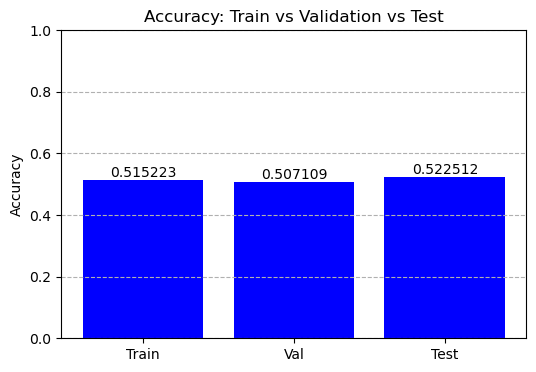

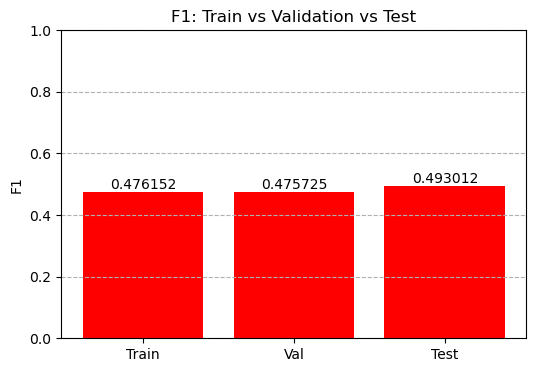

In [32]:
plots_metricas(df)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


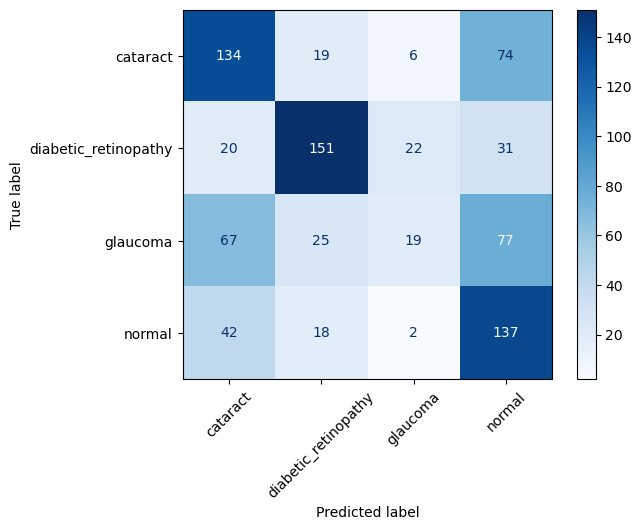

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm,  
                    display_labels= ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
                    ).plot(cmap="Blues", xticks_rotation= 45.0)

In [34]:
from sklearn.metrics import precision_recall_fscore_support

def per_class_table(model, datasets):
    # class_names: lista con nombres de las clases en el orden de los índices (opcional)
    class_names = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]  

    splits = list(datasets.keys())
    # identificamos número de clases desde los datos si no dan nombres
    sample_X, sample_y = next(iter(datasets.values()))
    n_classes = np.argmax(sample_y, axis=1).max() + 1

    # DataFrame con index = clases y columnas por split/metric
    cols = []
    for s in splits:
        cols += [f"{s}_Accuracy", f"{s}_F1"]
    df = pd.DataFrame(index=class_names, columns=cols, dtype=float)

    for split in splits:
        X, y = datasets[split]
        y_true = np.argmax(y, axis=1)
        y_pred = np.argmax(model.predict(X), axis=1)

        # precision, recall, f1 por clase
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, labels=np.arange(n_classes), zero_division=0
        )
        # Aquí definimos "Accuracy" por clase como recall (TP / nº verdaderos de la clase)
        for i, cls in enumerate(class_names):
            df.loc[cls, f"{split}_Accuracy"] = recall[i]
            df.loc[cls, f"{split}_F1"] = f1[i]

    return df

df_per_class = per_class_table(model, datasets)
df_per_class.round(3)

80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


,Train_Accuracy,Train_F1,Val_Accuracy,Val_F1,Test_Accuracy,Test_F1
cataract,0.505,0.479,0.527,0.492,0.575,0.540
diabetic_retinopathy,0.731,0.739,0.675,0.698,0.674,0.691
glaucoma,0.079,0.130,0.087,0.139,0.101,0.160
normal,0.727,0.545,0.688,0.527,0.688,0.529


Modelo Conv 16 -> Conv 32 --> Falten:
            Train   Val  Test

Accuracy   0.946  0.678  0.68

F1         0.946  0.681  0.684

Modelo Conv 16 -> Conv 32 -> Conv 64 --> GlobalAverage:
         Train    Val   Test

Accuracy  0.763  0.748  0.741
F1        0.753  0.741  0.731

Modelo Conv 16 -> Conv 32 -> Conv 64 --> Flaten:
          Train    Val   Test
Accuracy  0.958  0.660  0.701
F1        0.958  0.661  0.698